<h2><span style="color:red">Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset</span></h2>


In [2]:
#importing the required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [3]:
#Loading the dataset
df = pd.read_csv("sales_data_with_discounts.csv")

In [4]:
#previewing the data
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [5]:
#identifying the numerical coloumns
numerical_cols = df.select_dtypes(include=['number'])
print(numerical_cols.columns.tolist())

['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']


<h2><span style="color:red">Descriptive statistics</span></h2>

In [6]:
# Calculate descriptive statistics with interpretations
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numerical_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode().values[0]
    std_val = df[col].std()
    
    print(f"\nColumn: {col}")
    print(f"Mean: {mean_val:.2f}")
    print(f"Median: {median_val:.2f}")
    print(f"Mode: {mode_val:.2f}")
    print(f"Standard Deviation: {std_val:.2f}")
    print("Interpretation:")
    print(f"- The average value of {col} is {mean_val:.2f}.")
    print(f"- 50% of the values are below {median_val:.2f} and 50% above (median).")
    print(f"- The most frequent value is {mode_val:.2f} (mode).")
    print(f"- The spread of data around the mean (standard deviation) is {std_val:.2f}.")
    print("-"*50)



Column: Volume
Mean: 5.07
Median: 4.00
Mode: 3.00
Standard Deviation: 4.23
Interpretation:
- The average value of Volume is 5.07.
- 50% of the values are below 4.00 and 50% above (median).
- The most frequent value is 3.00 (mode).
- The spread of data around the mean (standard deviation) is 4.23.
--------------------------------------------------

Column: Avg Price
Mean: 10453.43
Median: 1450.00
Mode: 400.00
Standard Deviation: 18079.90
Interpretation:
- The average value of Avg Price is 10453.43.
- 50% of the values are below 1450.00 and 50% above (median).
- The most frequent value is 400.00 (mode).
- The spread of data around the mean (standard deviation) is 18079.90.
--------------------------------------------------

Column: Total Sales Value
Mean: 33812.84
Median: 5700.00
Mode: 24300.00
Standard Deviation: 50535.07
Interpretation:
- The average value of Total Sales Value is 33812.84.
- 50% of the values are below 5700.00 and 50% above (median).
- The most frequent value is 24300

## <h2><span style="color:red">Data Visualization</span></h2>

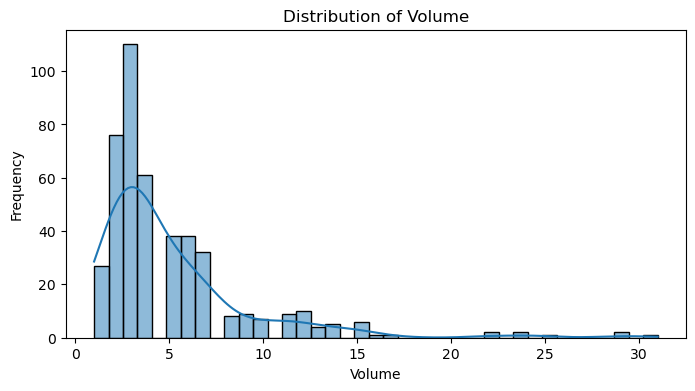

Analysis for Volume:
  Skewness: 2.731723626557714
  Kurtosis: 10.258547145181762
  Inference: The distribution is moderately or highly skewed.


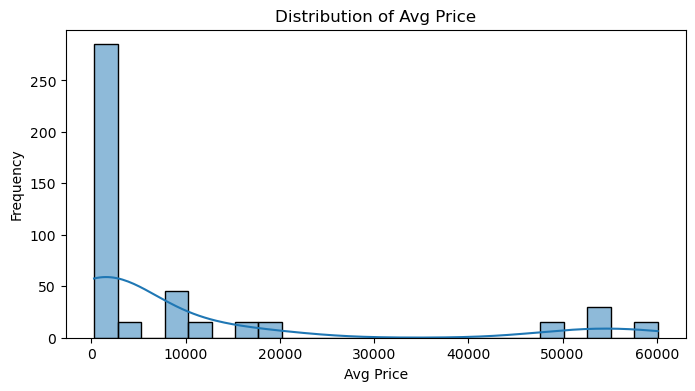

Analysis for Avg Price:
  Skewness: 1.9088730767759727
  Kurtosis: 2.07565498004372
  Inference: The distribution is moderately or highly skewed.


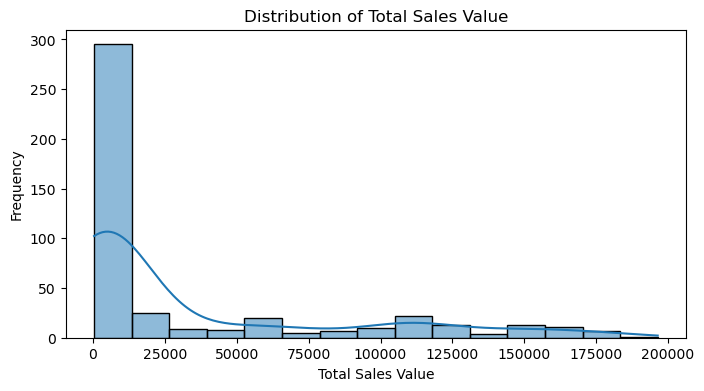

Analysis for Total Sales Value:
  Skewness: 1.5347293238977937
  Kurtosis: 1.0249161068455352
  Inference: The distribution is moderately or highly skewed.


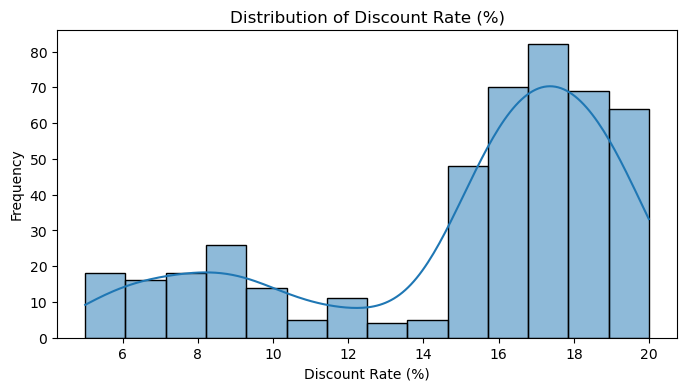

Analysis for Discount Rate (%):
  Skewness: -1.0622943696988825
  Kurtosis: -0.1785407468981699
  Inference: The distribution is moderately or highly skewed.


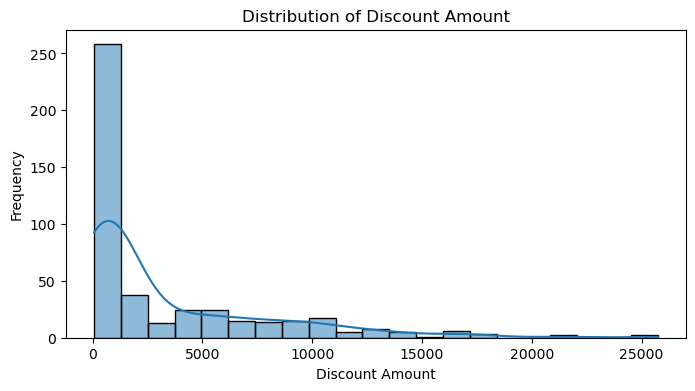

Analysis for Discount Amount:
  Skewness: 1.9130377339538271
  Kurtosis: 3.8311859719016343
  Inference: The distribution is moderately or highly skewed.


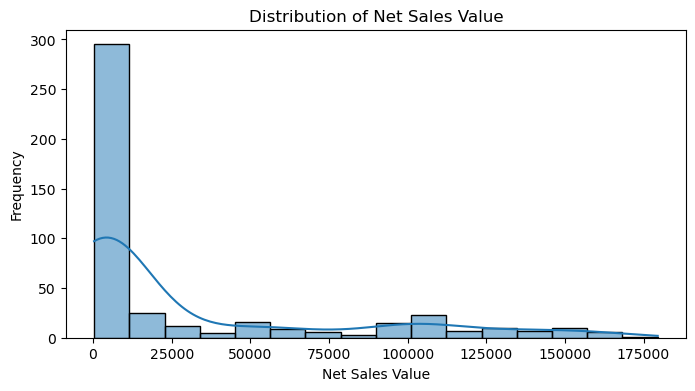

Analysis for Net Sales Value:
  Skewness: 1.5408217575344376
  Kurtosis: 1.0124678624199062
  Inference: The distribution is moderately or highly skewed.


In [15]:
#ploting histogram
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

    # Analyze distribution and provide inferences
    print(f"Analysis for {col}:")
    print(f"  Skewness: {df[col].skew()}")
    print(f"  Kurtosis: {df[col].kurtosis()}")

    # Basic inferences (can be expanded based on specific column characteristics)
    if abs(df[col].skew()) > 0.5:
        print("  Inference: The distribution is moderately or highly skewed.")
    else:
        print("  Inference: The distribution is relatively symmetrical.")

    if df[col].isnull().any():
        print("  Inference: This column contains missing values.")


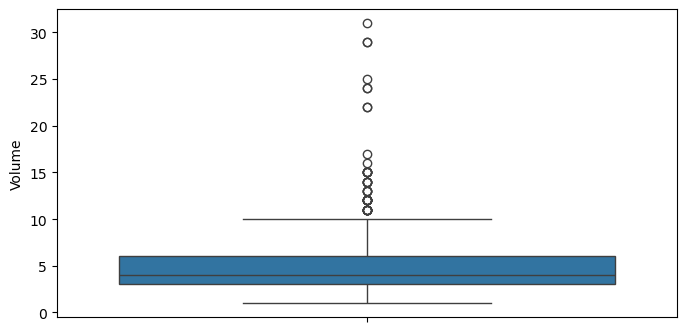

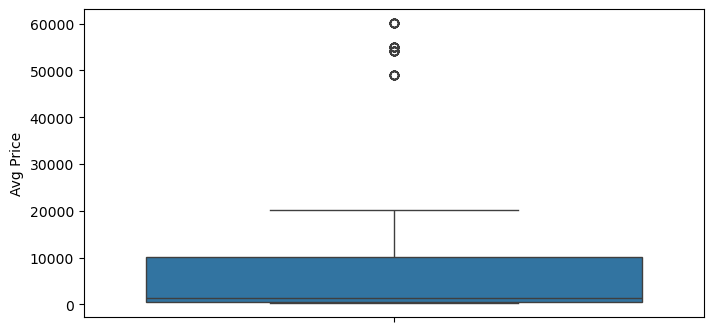

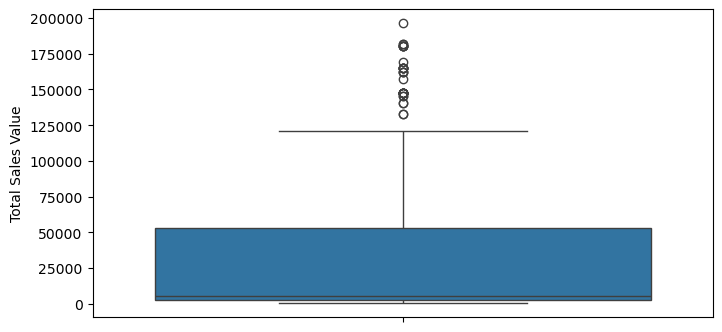

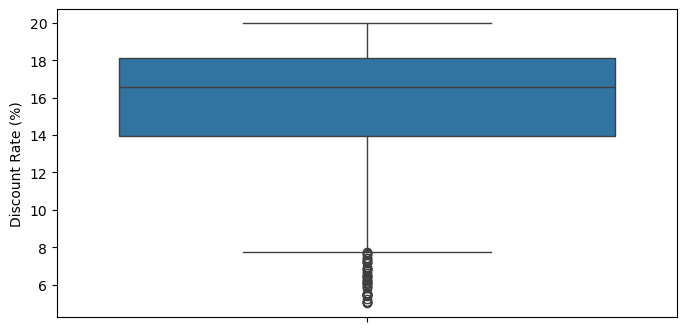

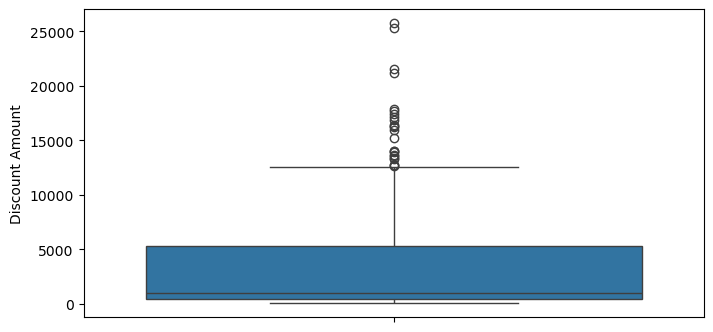

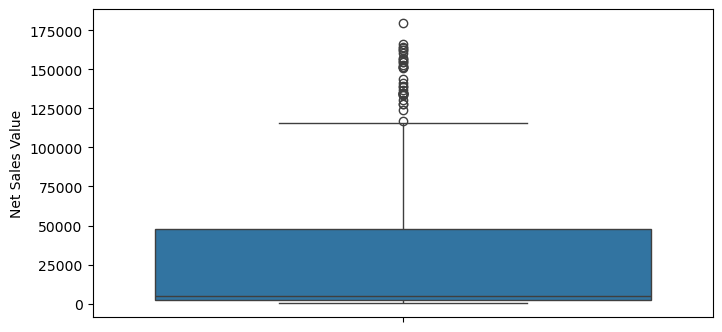

In [14]:
#PLOTING BOXPLOT
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(df[col])
    plt.show()

In [9]:
#Ploting BarChart 
categorical_cols = df.select_dtypes(include=['object']).columns

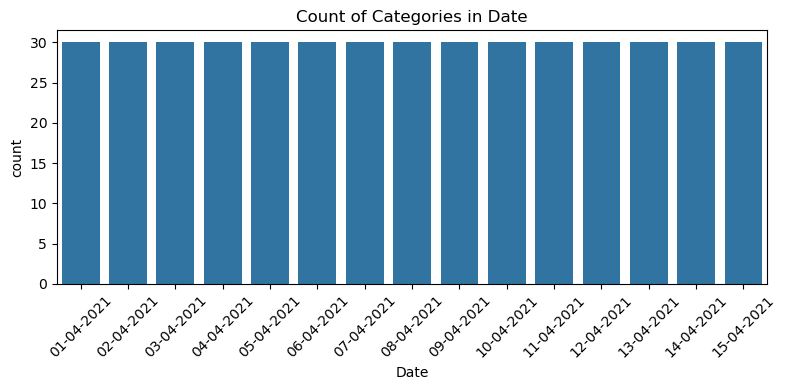

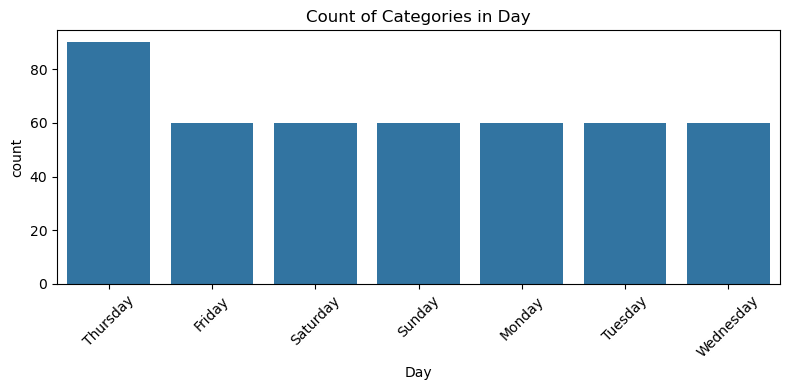

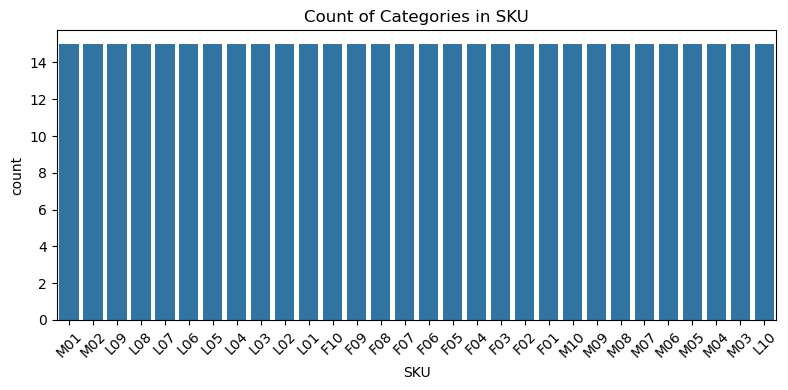

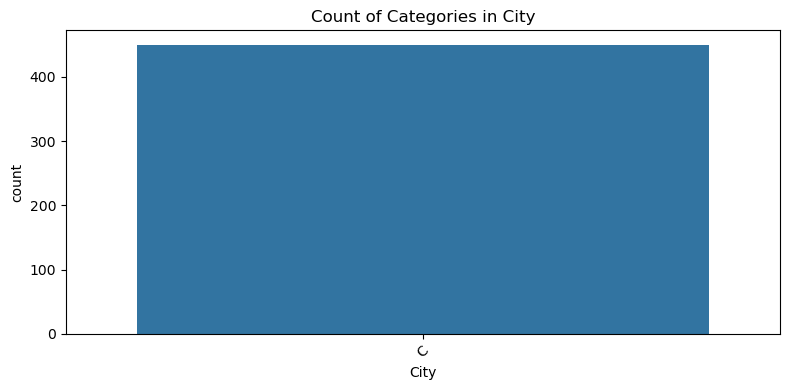

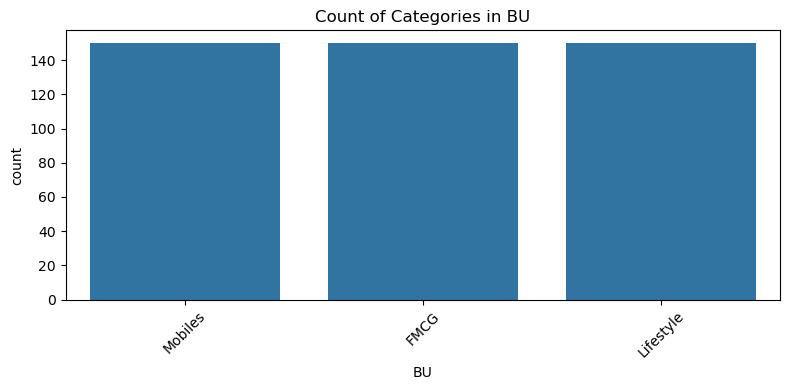

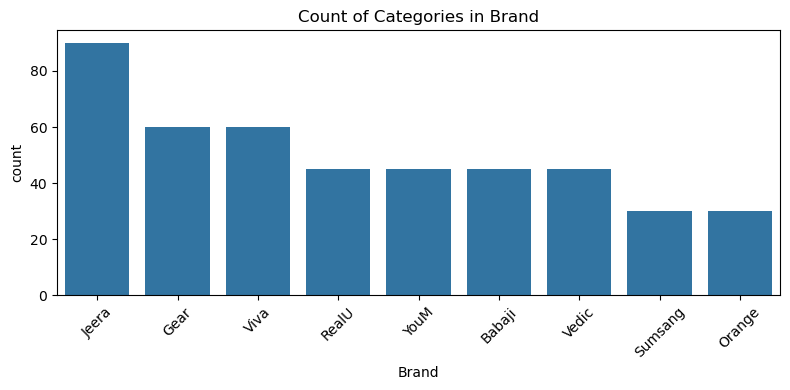

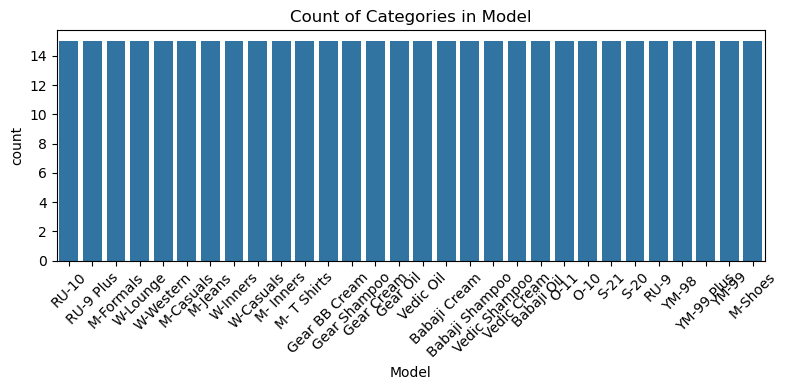

In [10]:

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Count of Categories in {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## <h2><span style="color:red">Standardization of Numerical Variables</span></h2>

In [11]:
# Assuming df is your original DataFrame
numerical_cols = df.select_dtypes(include=['number'])

# Save original for comparison
df_numerical_original = numerical_cols.copy()

# Apply Standardization
scaler = StandardScaler()
df_numerical_scaled = pd.DataFrame(scaler.fit_transform(numerical_cols), columns=numerical_cols.columns)

In [12]:
print("Before Standardization:\n", df_numerical_original.head())
print("\nAfter Standardization:\n", df_numerical_scaled.head())


Before Standardization:
    Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      15      12100             181500          11.654820     21153.498820   
1      10      10100             101000          11.560498     11676.102961   
2       7      16100             112700           9.456886     10657.910157   
3       6      20100             120600           6.935385      8364.074702   
4       3       8100              24300          17.995663      4372.946230   

   Net Sales Value  
0    160346.501180  
1     89323.897039  
2    102042.089843  
3    112235.925298  
4     19927.053770  

After Standardization:
      Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0  2.350029   0.091173           2.925721          -0.830289         3.952816   
1  1.167129  -0.019570           1.330995          -0.852661         1.849014   
2  0.457388   0.312659           1.562775          -1.351631         1.622995   
3  0.220808   0.534146   

## <h2><span style="color:red">Conversion of Categorical Data into Dummy Variables</span></h2>

In [20]:
#importing OneHotEncoder from Scikit-learn library
from sklearn.preprocessing import OneHotEncoder
OHE=OneHotEncoder()
OHE.fit_transform(df[["Brand"]])

<450x9 sparse matrix of type '<class 'numpy.float64'>'
	with 450 stored elements in Compressed Sparse Row format>

In [18]:
#  Previewing the values in the brand column
print(df['Brand'].value_counts())

Brand
Jeera      90
Gear       60
Viva       60
RealU      45
YouM       45
Babaji     45
Vedic      45
Sumsang    30
Orange     30
Name: count, dtype: int64


In [47]:
#   sorting the values in the brand column
val = df['Brand'].unique()
brands=sorted(val)
print(brands)

['Babaji', 'Gear', 'Jeera', 'Orange', 'RealU', 'Sumsang', 'Vedic', 'Viva', 'YouM']


In [44]:
OHE_COL=OHE.fit_transform(df[["Brand"]]).toarray()

In [45]:
#	Displaying  a portion of the transformed dataset.
OHE_COL=pd.DataFrame(OHE_COL)
OHE_COL.columns=brands
OHE_COL

,Babaji,Gear,Jeera,Orange,RealU,Sumsang,Vedic,Viva,YouM
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
445,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
446,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
447,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
448,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## <h2><span style="color:red">Conclusion</span></h2>

## Key Findings from Descriptive Analytics & Visualizations

## Descriptive Statistics:

 Calculated mean, median, mode, and standard deviation for all numerical columns.


Interpretation provided for each metric, e.g., average sales values, typical discount rates, and variation in net sales.

## Visualizations:

 Histograms were used to analyze distribution of numeric features like Total Sales Value, Net Sales, and Discount Amount.

Boxplots highlighted presence of outliers and skewness

 Bar Charts were used to visualize categorical data distributions such as Brand vs Net Sales or Model-wise Sales.These helped identify top-performing brands or models in terms of sales or discounts.

## Importance of standardization and one-hot encoding

 Standardization helps bring all numerical features to the same scale, making comparisons more meaningful and preventing any single feature from dominating due to its larger range. This is especially important in models that are sensitive to feature magnitude.

One-hot encoding transforms categorical data into a numeric format that machine learning models can understand. It ensures that categories are treated equally without implying any order or ranking between them.

Together, these preprocessing steps improve the quality and reliability of the data, making analysis more accurate and models more effective.